<a href="https://colab.research.google.com/github/Asaf21S/constrained-flow-matching/blob/main/flow_matching_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [2]:
!pip install torchcfm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 86.4 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchcfm.conditional_flow_matching import ConditionalFlowMatcher, ExactOptimalTransportConditionalFlowMatcher
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
import math

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Dataset

In [5]:
def get_mnist_loader(batch_size=128):
    transform = transforms.Compose([
        transforms.Pad(2),  # 28x28 -> 32x32
        transforms.ToTensor(),  # [0, 255] -> [0, 1]
        transforms.Normalize((0.5,), (0.5,))  # [0, 1] -> [-1, 1]
    ])

    dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)  # (tensor of size [batch, 1, 32, 32], gt digit)

In [6]:
dataloader = get_mnist_loader()

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.77MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 127kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.43MB/s]


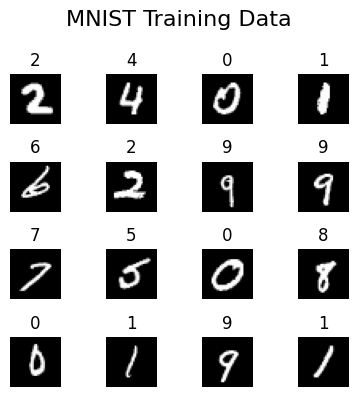

In [7]:
images, labels = next(iter(dataloader))

fig, axes = plt.subplots(4, 4, figsize=(4, 4))
fig.suptitle("MNIST Training Data", fontsize=16)

for i, ax in enumerate(axes.flat):
    # [-1, 1] -> [0, 1]
    img = (images[i] + 1) / 2
    img = img.clamp(0, 1)

    ax.imshow(img.squeeze(0).cpu().numpy(), cmap='gray')

    ax.set_title(f"{labels[i].item()}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Model definition

In [34]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

In [ ]:
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_channels)
        self.act1 = nn.SiLU()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)

        self.time_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_dim, out_channels)
        )

        self.norm2 = nn.GroupNorm(8, out_channels)
        self.act2 = nn.SiLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)

        self.residual = nn.Identity()
        if in_channels != out_channels:
            self.residual = nn.Conv2d(in_channels, out_channels, 1)

    def forward(self, x, t_emb):
        h = x
        h = self.norm1(h)
        h = self.act1(h)
        h = self.conv1(h)

        # Add time
        t_vec = self.time_proj(t_emb)[:, :, None, None]
        h = h + t_vec

        h = self.norm2(h)
        h = self.act2(h)
        h = self.conv2(h)

        return h + self.residual(x)

In [ ]:
class Downsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        # Strided conv reduces size by 2
        self.op = nn.Conv2d(channels, channels, 3, stride=2, padding=1)

    def forward(self, x):
        return self.op(x)

In [ ]:
class Upsample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="nearest")
        self.conv = nn.Conv2d(in_channels, out_channels, 3, padding=1)

    def forward(self, x):
        return self.conv(self.up(x))

In [ ]:
class ImprovedUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_c=64):
        super().__init__()
        time_dim = base_c * 4

        # Time Embedding
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(base_c),
            nn.Linear(base_c, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim),
        )

        # --- Encoder ---
        self.inc = nn.Conv2d(in_channels, base_c, 3, padding=1)

        # Level 1 (32x32)
        self.down1 = ResBlock(base_c, base_c, time_dim)
        self.ds1 = Downsample(base_c)

        # Level 2 (16x16)
        self.down2 = ResBlock(base_c, base_c * 2, time_dim)
        self.ds2 = Downsample(base_c * 2)

        # Level 3 (8x8)
        self.down3 = ResBlock(base_c * 2, base_c * 4, time_dim)
        self.ds3 = Downsample(base_c * 4)

        # --- Bottleneck (4x4) ---
        self.bot1 = ResBlock(base_c * 4, base_c * 4, time_dim)
        self.bot2 = ResBlock(base_c * 4, base_c * 4, time_dim)

        # --- Decoder ---
        # Level 3 (8x8)
        self.us3 = Upsample(base_c * 4, base_c * 4) # 4 -> 8
        self.dec3 = ResBlock(base_c * 8, base_c * 2, time_dim) # Input is 4c + 4c (skip) = 8c

        # Level 2 (16x16)
        self.us2 = Upsample(base_c * 2, base_c * 2) # 8 -> 16
        self.dec2 = ResBlock(base_c * 4, base_c, time_dim) # Input is 2c + 2c (skip) = 4c

        # Level 1 (32x32)
        self.us1 = Upsample(base_c, base_c) # 16 -> 32
        self.dec1 = ResBlock(base_c * 2, base_c, time_dim) # Input is c + c (skip) = 2c

        self.outc = nn.Conv2d(base_c, out_channels, 1)

    def forward(self, t, x):
        t = self.time_mlp(t)

        # Encoder
        x1 = self.inc(x)             # 32x32
        x1 = self.down1(x1, t)       # 32x32 (Skip connection 1)

        x2 = self.ds1(x1)            # 16x16
        x2 = self.down2(x2, t)       # 16x16 (Skip connection 2)

        x3 = self.ds2(x2)            # 8x8
        x3 = self.down3(x3, t)       # 8x8 (Skip connection 3)

        x4 = self.ds3(x3)            # 4x4
        x4 = self.bot1(x4, t)        # 4x4
        x4 = self.bot2(x4, t)

        # Decoder
        u3 = self.us3(x4)            # 8x8
        u3 = torch.cat([u3, x3], dim=1) # Concat (4c + 4c)
        u3 = self.dec3(u3, t)        # -> 2c

        u2 = self.us2(u3)            # 16x16
        u2 = torch.cat([u2, x2], dim=1) # Concat (2c + 2c)
        u2 = self.dec2(u2, t)        # -> c

        u1 = self.us1(u2)            # 32x32
        u1 = torch.cat([u1, x1], dim=1) # Concat (c + c)
        u1 = self.dec1(u1, t)

        return self.outc(u1)

# Train loop

In [ ]:
# Settings
model = ImprovedUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
FM = ExactOptimalTransportConditionalFlowMatcher(sigma=0.0)
epochs = 20

loss_list = []

In [ ]:
for epoch in tqdm(range(epochs)):
    epoch_loss = []
    for i, (images, labels) in tqdm(enumerate(dataloader), total=len(dataloader)):
        optimizer.zero_grad()

        x1 = images.to(device) # real image
        x0 = torch.randn_like(x1).to(device) # noise

        t, xt, real_vt = FM.sample_location_and_conditional_flow(x0, x1)
        pred_vt = model(t, xt)
        loss = torch.mean((pred_vt - real_vt) ** 2)
        epoch_loss.append(loss.item())

        loss.backward()
        optimizer.step()

    loss_list.extend(epoch_loss)
    print(np.mean(epoch_loss))

    if epoch + 1 % 10 == 0:
        torch.save(model.state_dict(), f"mnist_model_epoch_{epoch}.pth")

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/468 [00:00<?, ?it/s]

0.24643976470598808


  0%|          | 0/468 [00:00<?, ?it/s]

0.13436684668318838


...

0.09910919117685567


  0%|          | 0/468 [00:00<?, ?it/s]

0.09873175689488904


  0%|          | 0/468 [00:00<?, ?it/s]

0.09835469541259301


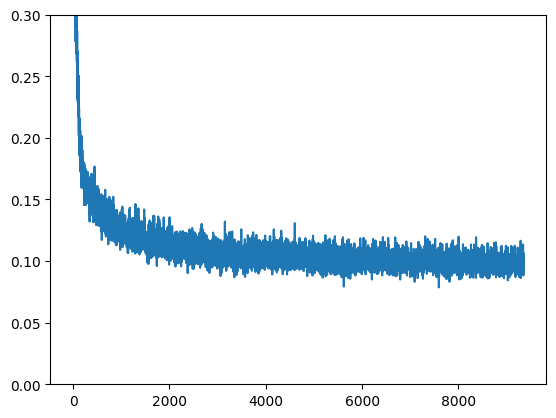

In [ ]:
plt.plot(loss_list)
plt.ylim(0, 0.3)
plt.show()

# Data sampler

In [23]:
def sample_mnist(model, n_samples, steps=100):
    model.eval()
    x = torch.randn(n_samples, 1, 32, 32).to(device)
    dt = 1.0 / steps

    traj = [x[0].clone().cpu()]
    with torch.no_grad():
        for i in range(steps):
            t = torch.ones(n_samples).to(device) * (i * dt)
            v = model(t, x)
            x = x + v * dt
            traj.append(x[0].clone().cpu())

    # [-1, 1] -> [0, 1]
    x = (x.clamp(-1, 1) + 1) / 2
    return x.cpu(), torch.stack(traj).numpy()  # traj size [steps, 1, 32, 32]

In [41]:
sampled_data, traj = sample_mnist(model, n_samples=16)

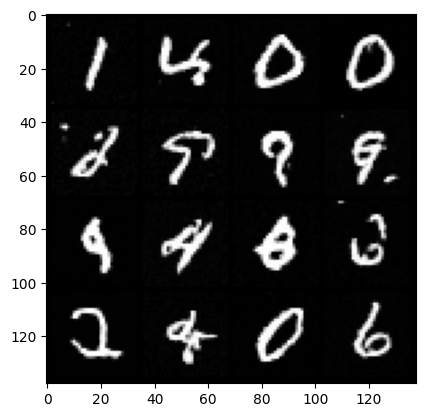

In [42]:
grid_img = torchvision.utils.make_grid(sampled_data, nrow=4)
plt.imshow(grid_img.permute(1, 2, 0))
plt.show()

In [39]:
def visualize_trajectory_snapshots(trajectory, num_snapshots=10):
    """
    trajectory: numpy array of shape [steps, 1, 32, 32]
    """
    steps = len(trajectory)
    # Pick indices evenly spaced from 0 to end
    indices = np.linspace(0, steps - 1, num_snapshots).astype(int)

    fig, axes = plt.subplots(1, num_snapshots, figsize=(15, 3))

    for i, idx in enumerate(indices):
        # 1. Get image and remove channel dim: [1, 32, 32] -> [32, 32]
        img = trajectory[idx].squeeze()

        # 2. Un-normalize for display: [-1, 1] -> [0, 1]
        img = (img + 1) / 2
        img = np.clip(img, 0, 1)

        # 3. Plot
        axes[i].imshow(img, cmap='gray')

        # Calculate time t (approx)
        t = idx / (steps - 1)
        axes[i].set_title(f"t={t:.1f}", fontsize=10)
        axes[i].axis('off')

    plt.suptitle(f"Generation Trajectory (Digit Emergence)", fontsize=14)
    plt.tight_layout()
    plt.show()

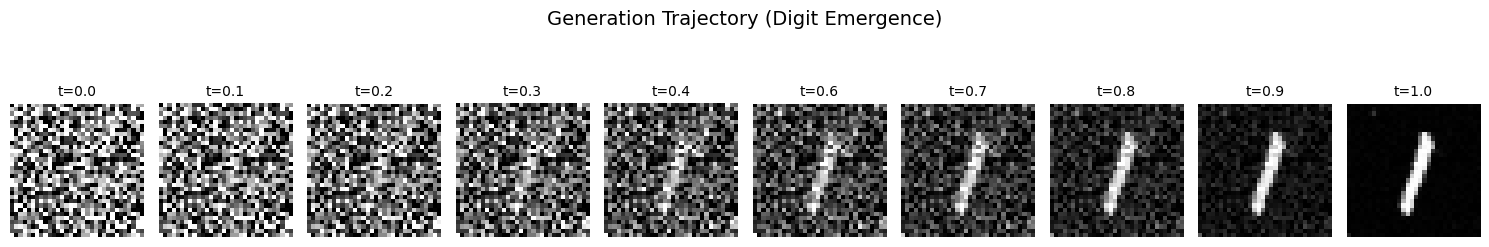

In [43]:
visualize_trajectory_snapshots(traj)

In [25]:
import matplotlib.animation as animation
from IPython.display import HTML

def animate_trajectory(trajectory):
    """
    Creates an animation from the trajectory array.
    """
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.axis('off')

    # Setup the initial empty plot
    # We un-normalize the first frame
    img_data = (trajectory[0].squeeze() + 1) / 2
    img_data = np.clip(img_data, 0, 1)
    im = ax.imshow(img_data, cmap='gray', animated=True)
    title = ax.set_title("t=0.00")

    def update(frame_idx):
        # Update image data
        img = trajectory[frame_idx].squeeze()
        img = (img + 1) / 2
        img = np.clip(img, 0, 1)

        im.set_array(img)

        # Update title
        t = frame_idx / (len(trajectory) - 1)
        title.set_text(f"t={t:.2f}")
        return im, title

    # Create animation
    ani = animation.FuncAnimation(
        fig, update, frames=len(trajectory), interval=50, blit=True
    )

    plt.close() # Prevent double display in notebooks
    return ani

In [43]:
ani = animate_trajectory(traj)
HTML(ani.to_jshtml())